<a href="https://colab.research.google.com/github/diablo-10/ML-laab/blob/main/Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
#load california housing dataset
housing=fetch_california_housing(as_frame=True)
df=housing.frame

In [ ]:
X=df[['AveRooms']].values
Y=df['MedHouseVal'].values.reshape(-1,1)

In [ ]:
#Add bias time
X_b=np.c_[np.ones((len(X),1)),X]

In [ ]:
theta_normal=np.linalg.inv(X_b.T @ X_b)@ X_b.T @ y
y_pred_normal=X_b @ theta_normal

print("---------------Normal Education------------")
print("Intercept :",theta_normal[0][0])
print("Slope     :",theta_normal[1],[0])
print("MSE       :",mean_squared_error(y,y_pred_normal))
print("R2 score  :",r2_score(y,y_pred_normal))

---------------Normal Education------------
Intercept : 1.6838115086404832
Slope     : [0.07086879] [0]
MSE       : 1.3008070902505424
R2 score  : 0.023088282755354017


In [ ]:
def compute_cost(X,y,theta):
  m=len(y)
  predictions=X@theta
  cost=(1/(2*m))*np.sum((predictions-y)*2)
  return cost

def gradient_descent(X,y,theta,learning_rate,iterations):
  m=len(y)
  cost_history=[]
  for i in range(iterations):
    gradients=(1/m)*X.T@(X@theta-y)
    theta=theta-learning_rate*gradients
    cost_history.append(compute_cost(X,y,theta))
  return theta,cost_history
theta=np.zeros((2,1))
learning_rate=0.001
iterations=1000
theta_gd,cost_history=gradient_descent(X_b,y,theta,learning_rate,iterations)

y_pred_gd=X_b@theta_gd
print("-----------Gradient Descent----------")
print("Intercept :",theta_gd[0][0])
print("Slope     :",theta_gd[1][0])
print("MSE       :",mean_squared_error(y,y_pred_gd))
print("R2 score  :",r2_score(y,y_pred_gd))

-----------Gradient Descent----------
Intercept : 0.30209997653075465
Slope     : 0.2826073529823789
MSE       : 1.6291507228490774
R2 score  : -0.22349919695034104


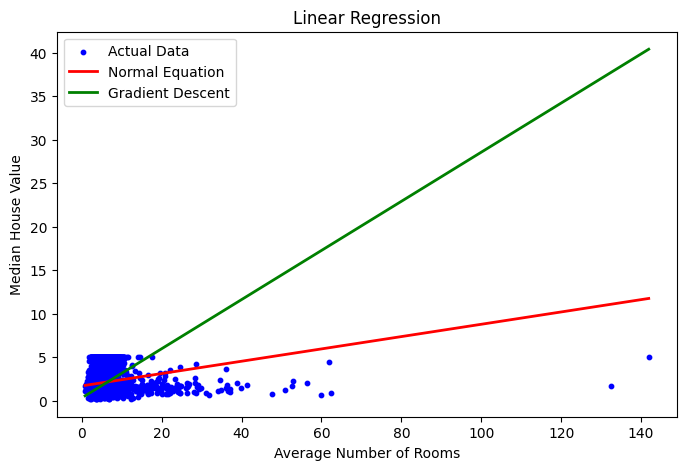

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

# Data Loading and Preprocessing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1,1)

# Add bias term
X_b = np.c_[np.ones((len(X),1)), X]

# Normal Equation calculations
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
y_pred_normal = X_b @ theta_normal

# Gradient Descent functions and calculations
def compute_cost(X, y, theta):
  m = len(y)
  predictions = X @ theta
  cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
  return cost

def gradient_descent(X, y, theta, learning_rate, iterations):
  m = len(y)
  cost_history = []
  for i in range(iterations):
    gradients = (1 / m) * X.T @ (X @ theta - y)
    theta = theta - learning_rate * gradients
    cost_history.append(compute_cost(X, y, theta))
  return theta, cost_history

theta = np.zeros((2,1))
learning_rate = 0.001
iterations = 1000
theta_gd, cost_history = gradient_descent(X_b, y, theta, learning_rate, iterations)
y_pred_gd = X_b @ theta_gd

# Plotting code
sort_index = np.argsort(X.flatten())

plt.figure(figsize=(8,5))

plt.scatter(X, y, s=10, color='blue', label='Actual Data')

plt.plot(X[sort_index],
         y_pred_normal[sort_index],
         color='red',
         linewidth=2,
         label='Normal Equation')

plt.plot(X[sort_index],
         y_pred_gd[sort_index],
         color='green',
         linewidth=2,
         label='Gradient Descent')

plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value")
plt.title("Linear Regression")
plt.legend()
plt.show()

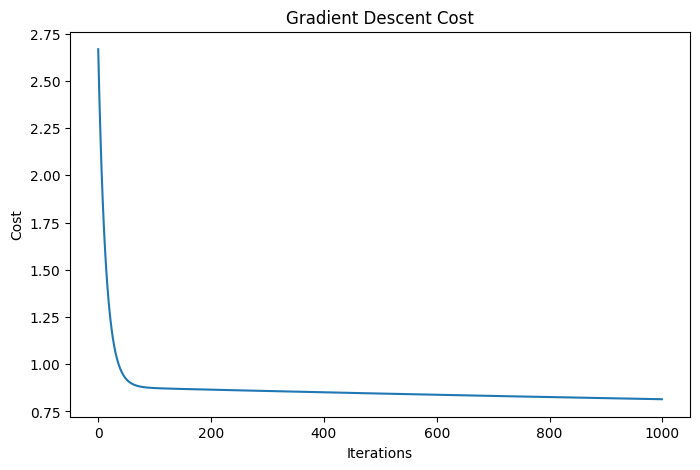

In [10]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")
plt.show()
